In [1]:
import pandas as pd

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report

In [ ]:
df = pd.read_csv('../../datasets/winequality-red.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.shape

(1599, 12)

In [4]:
df['quality'].unique()

array([5, 6, 7, 4, 8, 3], dtype=int64)

array([[<AxesSubplot:title={'center':'quality'}>]], dtype=object)

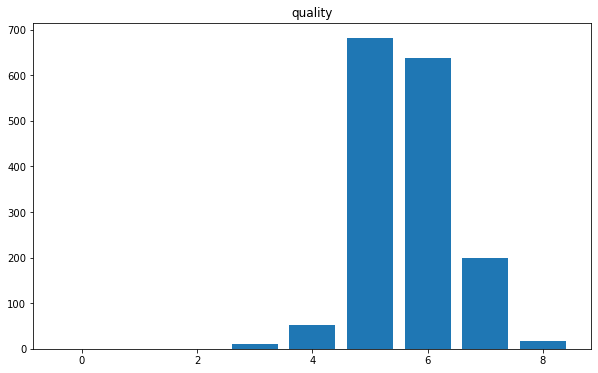

In [5]:
df.hist(column='quality', figsize=(10,6), bins=np.arange(10) - 0.5, grid=False, rwidth=0.8)

In [6]:
df['high_quality'] = df['quality'].apply(lambda rating : 1 if rating > 5 else 0)

In [7]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,high_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


array([[<AxesSubplot:title={'center':'high_quality'}>]], dtype=object)

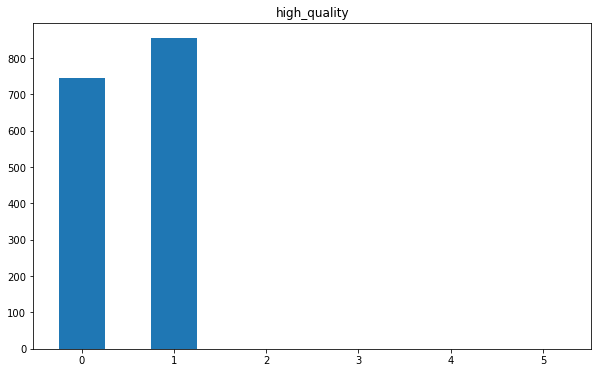

In [8]:
df.hist(column='high_quality', figsize=(10,6), bins=np.arange(7) - 0.5, grid=False, rwidth=0.5)

In [9]:
X = df.drop(['quality', 'high_quality'], axis=1)
Y = df['high_quality']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

x_train, x_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=1)

In [10]:
x_train.shape, y_train.shape

((1279, 11), (1279,))

In [11]:
x_test.shape, y_test.shape

((320, 11), (320,))

In [12]:
model = LinearSVC(C=1.0, max_iter=1000, tol=1e-3, dual=False).fit(x_train, y_train)
y_pred = model.predict(x_test)
pred_results = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred})
df_crosstab = pd.crosstab(pred_results.y_pred, pred_results.y_test)
df_crosstab

y_test,0,1
y_pred,,
0,114,41
1,40,125


In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.74      0.74       154
           1       0.76      0.75      0.76       166

    accuracy                           0.75       320
   macro avg       0.75      0.75      0.75       320
weighted avg       0.75      0.75      0.75       320



In [14]:
X = df.drop(['quality', 'high_quality'], axis=1)
Y = df['high_quality']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

x_train, x_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=1)

In [15]:
from sklearn.model_selection import GridSearchCV
parameters = {'C': [0.1, 1, 10, 100, 1000], 'tol': [1e-4], 'kernel': ['linear']} 
grid = GridSearchCV(SVC(), parameters, cv=3, verbose=2)
grid.fit(x_train,y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END ...................C=0.1, kernel=linear, tol=0.0001; total time=   0.0s
[CV] END ...................C=0.1, kernel=linear, tol=0.0001; total time=   0.0s
[CV] END ...................C=0.1, kernel=linear, tol=0.0001; total time=   0.0s
[CV] END .....................C=1, kernel=linear, tol=0.0001; total time=   0.0s
[CV] END .....................C=1, kernel=linear, tol=0.0001; total time=   0.0s
[CV] END .....................C=1, kernel=linear, tol=0.0001; total time=   0.0s
[CV] END ....................C=10, kernel=linear, tol=0.0001; total time=   0.0s
[CV] END ....................C=10, kernel=linear, tol=0.0001; total time=   0.0s
[CV] END ....................C=10, kernel=linear, tol=0.0001; total time=   0.0s
[CV] END ...................C=100, kernel=linear, tol=0.0001; total time=   1.5s
[CV] END ...................C=100, kernel=linear, tol=0.0001; total time=   0.5s
[CV] END ...................C=100, kernel=linear,

GridSearchCV(cv=3, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000], 'kernel': ['linear'],
                         'tol': [0.0001]},
             verbose=2)

In [16]:
print(grid.best_estimator_)

SVC(C=1, kernel='linear', tol=0.0001)


In [17]:
from sklearn.metrics import confusion_matrix  
y_pred = grid.predict(x_test)
print(confusion_matrix(y_test, y_pred))

[[116  38]
 [ 47 119]]


In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.75      0.73       154
           1       0.76      0.72      0.74       166

    accuracy                           0.73       320
   macro avg       0.73      0.74      0.73       320
weighted avg       0.74      0.73      0.73       320



In [19]:
X = df.drop(['quality', 'high_quality'], axis=1)
Y = df['high_quality']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

x_train, x_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=1)

In [20]:
parameters = svm_others = {'C': [0.1, 1, 10], 'gamma': [1, 0.1, 0.01, 'scale', 'auto'], 'tol': [1e-4], 'kernel': ['poly']}
grid = GridSearchCV(SVC(), parameters, cv=3, verbose=2)
grid.fit(x_train,y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END ............C=0.1, gamma=1, kernel=poly, tol=0.0001; total time=   0.1s
[CV] END ............C=0.1, gamma=1, kernel=poly, tol=0.0001; total time=   0.2s
[CV] END ............C=0.1, gamma=1, kernel=poly, tol=0.0001; total time=   0.1s
[CV] END ..........C=0.1, gamma=0.1, kernel=poly, tol=0.0001; total time=   0.0s
[CV] END ..........C=0.1, gamma=0.1, kernel=poly, tol=0.0001; total time=   0.0s
[CV] END ..........C=0.1, gamma=0.1, kernel=poly, tol=0.0001; total time=   0.0s
[CV] END .........C=0.1, gamma=0.01, kernel=poly, tol=0.0001; total time=   0.0s
[CV] END .........C=0.1, gamma=0.01, kernel=poly, tol=0.0001; total time=   0.0s
[CV] END .........C=0.1, gamma=0.01, kernel=poly, tol=0.0001; total time=   0.0s
[CV] END ........C=0.1, gamma=scale, kernel=poly, tol=0.0001; total time=   0.0s
[CV] END ........C=0.1, gamma=scale, kernel=poly, tol=0.0001; total time=   0.0s
[CV] END ........C=0.1, gamma=scale, kernel=poly

GridSearchCV(cv=3, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10],
                         'gamma': [1, 0.1, 0.01, 'scale', 'auto'],
                         'kernel': ['poly'], 'tol': [0.0001]},
             verbose=2)

In [21]:
print(grid.best_estimator_)

SVC(C=1, gamma=0.1, kernel='poly', tol=0.0001)


In [22]:
from sklearn.metrics import confusion_matrix  
y_pred = grid.predict(x_test)
print(confusion_matrix(y_test, y_pred))

[[112  42]
 [ 42 124]]


In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.73      0.73       154
           1       0.75      0.75      0.75       166

    accuracy                           0.74       320
   macro avg       0.74      0.74      0.74       320
weighted avg       0.74      0.74      0.74       320



In [24]:
X = df.drop(['quality', 'high_quality'], axis=1)
Y = df['high_quality']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

x_train, x_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=1)

In [25]:
parameters = svm_others = {'C': [0.1, 1, 10], 'gamma': [1, 0.1, 0.01, 'scale', 'auto'], 'tol': [1e-4], 'kernel': ['rbf']}
grid = GridSearchCV(SVC(), parameters, cv=3, verbose=2)
grid.fit(x_train,y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END .............C=0.1, gamma=1, kernel=rbf, tol=0.0001; total time=   0.0s
[CV] END .............C=0.1, gamma=1, kernel=rbf, tol=0.0001; total time=   0.0s
[CV] END .............C=0.1, gamma=1, kernel=rbf, tol=0.0001; total time=   0.0s
[CV] END ...........C=0.1, gamma=0.1, kernel=rbf, tol=0.0001; total time=   0.0s
[CV] END ...........C=0.1, gamma=0.1, kernel=rbf, tol=0.0001; total time=   0.0s
[CV] END ...........C=0.1, gamma=0.1, kernel=rbf, tol=0.0001; total time=   0.0s
[CV] END ..........C=0.1, gamma=0.01, kernel=rbf, tol=0.0001; total time=   0.0s
[CV] END ..........C=0.1, gamma=0.01, kernel=rbf, tol=0.0001; total time=   0.0s
[CV] END ..........C=0.1, gamma=0.01, kernel=rbf, tol=0.0001; total time=   0.0s
[CV] END .........C=0.1, gamma=scale, kernel=rbf, tol=0.0001; total time=   0.0s
[CV] END .........C=0.1, gamma=scale, kernel=rbf, tol=0.0001; total time=   0.0s
[CV] END .........C=0.1, gamma=scale, kernel=rbf

GridSearchCV(cv=3, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10],
                         'gamma': [1, 0.1, 0.01, 'scale', 'auto'],
                         'kernel': ['rbf'], 'tol': [0.0001]},
             verbose=2)

In [26]:
print(grid.best_estimator_)

SVC(C=1, gamma=0.1, tol=0.0001)


In [27]:
from sklearn.metrics import confusion_matrix  
y_pred = grid.predict(x_test)
print(confusion_matrix(y_test, y_pred))

[[115  39]
 [ 44 122]]


In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.75      0.73       154
           1       0.76      0.73      0.75       166

    accuracy                           0.74       320
   macro avg       0.74      0.74      0.74       320
weighted avg       0.74      0.74      0.74       320



In [29]:
X = df.drop(['quality', 'high_quality'], axis=1)
Y = df['high_quality']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

x_train, x_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=1)

In [30]:
parameters = svm_others = {'C': [0.1, 1, 10], 'gamma': [1, 0.1, 0.01, 'scale', 'auto'], 'tol': [1e-4], 'kernel': ['sigmoid']}
grid = GridSearchCV(SVC(), parameters, cv=3, verbose=2)
grid.fit(x_train,y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END .........C=0.1, gamma=1, kernel=sigmoid, tol=0.0001; total time=   0.0s
[CV] END .........C=0.1, gamma=1, kernel=sigmoid, tol=0.0001; total time=   0.0s
[CV] END .........C=0.1, gamma=1, kernel=sigmoid, tol=0.0001; total time=   0.0s
[CV] END .......C=0.1, gamma=0.1, kernel=sigmoid, tol=0.0001; total time=   0.0s
[CV] END .......C=0.1, gamma=0.1, kernel=sigmoid, tol=0.0001; total time=   0.0s
[CV] END .......C=0.1, gamma=0.1, kernel=sigmoid, tol=0.0001; total time=   0.0s
[CV] END ......C=0.1, gamma=0.01, kernel=sigmoid, tol=0.0001; total time=   0.0s
[CV] END ......C=0.1, gamma=0.01, kernel=sigmoid, tol=0.0001; total time=   0.0s
[CV] END ......C=0.1, gamma=0.01, kernel=sigmoid, tol=0.0001; total time=   0.0s
[CV] END .....C=0.1, gamma=scale, kernel=sigmoid, tol=0.0001; total time=   0.0s
[CV] END .....C=0.1, gamma=scale, kernel=sigmoid, tol=0.0001; total time=   0.0s
[CV] END .....C=0.1, gamma=scale, kernel=sigmoid

GridSearchCV(cv=3, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10],
                         'gamma': [1, 0.1, 0.01, 'scale', 'auto'],
                         'kernel': ['sigmoid'], 'tol': [0.0001]},
             verbose=2)

In [31]:
print(grid.best_estimator_)

SVC(C=10, gamma=0.01, kernel='sigmoid', tol=0.0001)


In [32]:
from sklearn.metrics import confusion_matrix  
y_pred = grid.predict(x_test)
print(confusion_matrix(y_test, y_pred))

[[115  39]
 [ 46 120]]


In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.75      0.73       154
           1       0.75      0.72      0.74       166

    accuracy                           0.73       320
   macro avg       0.73      0.73      0.73       320
weighted avg       0.74      0.73      0.73       320



In [34]:
X = df.drop(['quality', 'high_quality'], axis=1)
Y = df['high_quality']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

x_train, x_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=1)

In [35]:
model = SVC(kernel='poly', gamma='auto', C=0.1, max_iter=100000, tol=1e-4).fit(x_train, y_train)

In [36]:
y_pred = model.predict(x_test)

In [37]:
pred_results = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred})

In [38]:
pred_results.head()

,y_test,y_pred
75,0,1
1283,1,1
408,1,1
1281,1,1
1118,1,1


In [39]:
df_crosstab = pd.crosstab(pred_results.y_pred, pred_results.y_test)
df_crosstab

y_test,0,1
y_pred,,
0,109,32
1,45,134


In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.71      0.74       154
           1       0.75      0.81      0.78       166

    accuracy                           0.76       320
   macro avg       0.76      0.76      0.76       320
weighted avg       0.76      0.76      0.76       320

